**Import Library**

In [49]:
import pandas as pd
import numpy as np
import datetime as dt
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

**Load the datase**

In [50]:

#  using ISO-8859-1 encoding to avoid UnicodeDecodeError
df = pd.read_csv('Online Retail.csv', encoding='ISO-8859-1')

# Display the first 5 rows to verify the data
print(df.head())

# Display dataset information
print(df.info())

  ï»¿InvoiceNo StockCode                          Description  Quantity  \
0       536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1       536365     71053                  WHITE METAL LANTERN         6   
2       536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3       536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4       536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

    InvoiceDate  UnitPrice  CustomerID         Country  
0  12/1/10 8:26       2.55     17850.0  United Kingdom  
1  12/1/10 8:26       3.39     17850.0  United Kingdom  
2  12/1/10 8:26       2.75     17850.0  United Kingdom  
3  12/1/10 8:26       3.39     17850.0  United Kingdom  
4  12/1/10 8:26       3.39     17850.0  United Kingdom  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   ï»¿I

**Data Cleaning For RFM analysis**

In [51]:
# 1. Drop rows with missing CustomerID
df = df.dropna(subset=['CustomerID'])

# 2. Filter out transactions with non-positive Quantity or UnitPrice
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]

# 3. Drop duplicate records
df = df.drop_duplicates()

# 4. Convert InvoiceDate to datetime objects
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# 5. Convert CustomerID to integer (it often loads as float)
df['CustomerID'] = df['CustomerID'].astype(int)

# 6. Create a TotalSum column (Monetary value)
df['TotalSum'] = df['Quantity'] * df['UnitPrice']

# Verify the cleaned data
print(df.shape)
print(df.head())

/tmp/ipython-input-3823222068.py:11: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])


(392692, 9)
  ï»¿InvoiceNo StockCode                          Description  Quantity  \
0       536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1       536365     71053                  WHITE METAL LANTERN         6   
2       536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3       536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4       536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  UnitPrice  CustomerID         Country  TotalSum  
0 2010-12-01 08:26:00       2.55       17850  United Kingdom     15.30  
1 2010-12-01 08:26:00       3.39       17850  United Kingdom     20.34  
2 2010-12-01 08:26:00       2.75       17850  United Kingdom     22.00  
3 2010-12-01 08:26:00       3.39       17850  United Kingdom     20.34  
4 2010-12-01 08:26:00       3.39       17850  United Kingdom     20.34  


In [52]:

# 1. Fix the column name
if 'ï»¿InvoiceNo' in df.columns:
    df.rename(columns={'ï»¿InvoiceNo': 'InvoiceNo'}, inplace=True)

# 2. Re-verify columns to be sure
print("Corrected columns:", df.columns.tolist())

# 3. Define a snapshot date
snapshot_date = df['InvoiceDate'].max() + dt.timedelta(days=1)

# 4. Aggregate data by CustomerID to calculate Recency, Frequency, and Monetary
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days, # Recency
    'InvoiceNo': 'nunique',                                 # Frequency
    'TotalSum': 'sum'                                       # Monetary
})

# 5. Rename the columns for the RFM table
rfm.rename(columns={
    'InvoiceDate': 'Recency',
    'InvoiceNo': 'Frequency',
    'TotalSum': 'MonetaryValue'
}, inplace=True)

# 6. Display the first few rows
print(rfm.head())

# 7. Check the summary statistics
print(rfm.describe())

Corrected columns: ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country', 'TotalSum']
            Recency  Frequency  MonetaryValue
CustomerID                                   
12346           326          1       77183.60
12347             2          7        4310.00
12348            75          4        1797.24
12349            19          1        1757.55
12350           310          1         334.40
           Recency    Frequency  MonetaryValue
count  4338.000000  4338.000000    4338.000000
mean     92.536422     4.272015    2048.688081
std     100.014169     7.697998    8985.230220
min       1.000000     1.000000       3.750000
25%      18.000000     1.000000     306.482500
50%      51.000000     2.000000     668.570000
75%     142.000000     5.000000    1660.597500
max     374.000000   209.000000  280206.020000


In [53]:

# 1. Calculate quartiles for Recency, Frequency, and Monetary
# For Recency: lower is better (rank 4 for lowest recency)
r_labels = range(4, 0, -1)
r_groups = pd.qcut(rfm['Recency'], q=4, labels=r_labels)

# For Frequency: higher is better (rank 4 for highest frequency)
f_labels = range(1, 5)
f_groups = pd.qcut(rfm['Frequency'].rank(method='first'), q=4, labels=f_labels)

# For Monetary: higher is better (rank 4 for highest value)
m_labels = range(1, 5)
m_groups = pd.qcut(rfm['MonetaryValue'], q=4, labels=m_labels)

# 2. Add the scores to the RFM dataframe
rfm['R'] = r_groups.astype(int)
rfm['F'] = f_groups.astype(int)
rfm['M'] = m_groups.astype(int)

# 3. Calculate the total RFM Score (Sum of R, F, and M)
rfm['RFM_Score'] = rfm[['R', 'F', 'M']].sum(axis=1)

# 4. Create customer segments based on the RFM Score
def segment_me(df):
    if df['RFM_Score'] >= 10:
        return 'Best Customers'
    elif (df['RFM_Score'] >= 8) and (df['RFM_Score'] < 10):
        return 'Loyal Customers'
    elif (df['RFM_Score'] >= 6) and (df['RFM_Score'] < 8):
        return 'Potential Loyalist'
    elif (df['RFM_Score'] >= 4) and (df['RFM_Score'] < 6):
        return 'At Risk'
    else:
        return 'Lost'

rfm['Segment'] = rfm.apply(segment_me, axis=1)

# 5. Show the first few rows with segments
print("\n--- RFM Table with Segments ---")
print(rfm.head())

# 6. Check the distribution of segments
print(rfm['Segment'].value_counts())


--- RFM Table with Segments ---
            Recency  Frequency  MonetaryValue  R  F  M  RFM_Score  \
CustomerID                                                          
12346           326          1       77183.60  1  1  4          6   
12347             2          7        4310.00  4  4  4         12   
12348            75          4        1797.24  2  3  4          9   
12349            19          1        1757.55  3  1  4          8   
12350           310          1         334.40  1  1  2          4   

                       Segment  
CustomerID                      
12346       Potential Loyalist  
12347           Best Customers  
12348          Loyal Customers  
12349          Loyal Customers  
12350                  At Risk  
Segment
Best Customers        1267
At Risk                991
Potential Loyalist     935
Loyal Customers        845
Lost                   300
Name: count, dtype: int64


/tmp/ipython-input-4252577761.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=rfm, x='Segment', order=rfm['Segment'].value_counts().index, palette='viridis')


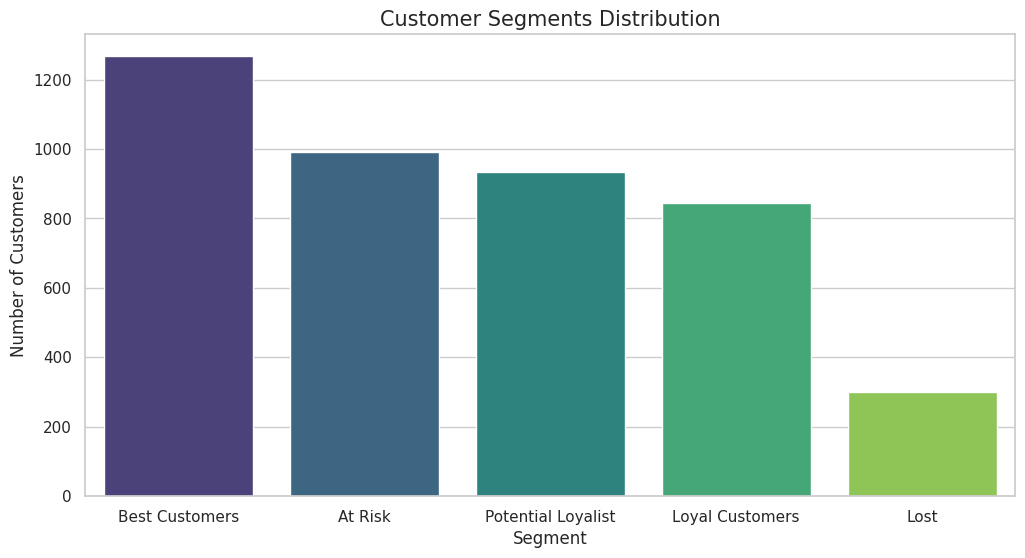

--- Average RFM Values per Segment ---
                       Recency  Frequency  MonetaryValue
Segment                                                 
Best Customers       19.915549   9.921863    5388.504949
Loyal Customers      52.459172   3.230769    1244.497019
Potential Loyalist   87.293048   1.863102     695.753104
At Risk             171.437941   1.199798     312.296429
Lost                267.826667   1.000000     161.194100


/tmp/ipython-input-4252577761.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Segment', y='MonetaryValue', data=rfm, palette='Set2')


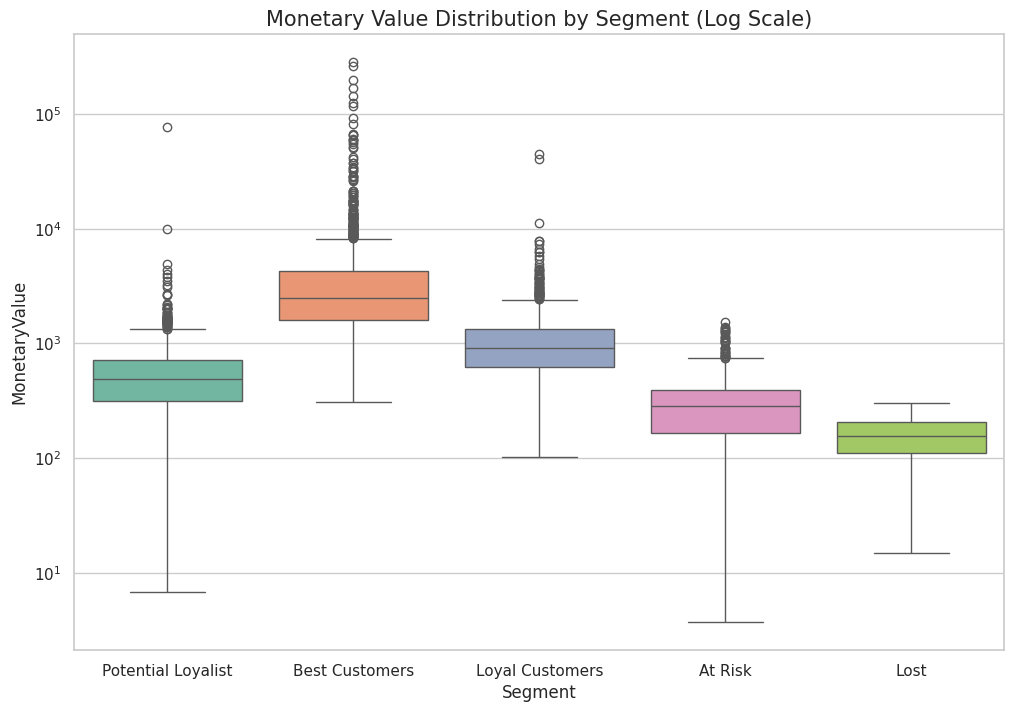

In [54]:
sns.set(style="whitegrid")

# 1. Visualize Segment Distribution
plt.figure(figsize=(12, 6))
sns.countplot(data=rfm, x='Segment', order=rfm['Segment'].value_counts().index, palette='viridis')
plt.title('Customer Segments Distribution', fontsize=15)
plt.xlabel('Segment', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.show()

# 2. Visualize the average Recency, Frequency, and Monetary for each Segment
segment_summary = rfm.groupby('Segment').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'MonetaryValue': 'mean'
}).sort_values(by='MonetaryValue', ascending=False)

print("--- Average RFM Values per Segment ---")
print(segment_summary)

# 3. Create a Box Plot to see the distribution of Monetary Value per segment
plt.figure(figsize=(12, 8))
sns.boxplot(x='Segment', y='MonetaryValue', data=rfm, palette='Set2')
plt.yscale('log') # Using log scale because Monetary values can have big outliers
plt.title('Monetary Value Distribution by Segment (Log Scale)', fontsize=15)
plt.show()

--- AI Generated Cluster Summary ---
         Recency  Frequency  MonetaryValue
Cluster                                   
0          21.80       1.83         454.58
1          10.33      13.07        7684.14
2         190.34       1.27         344.01
3          70.02       4.13        1720.98


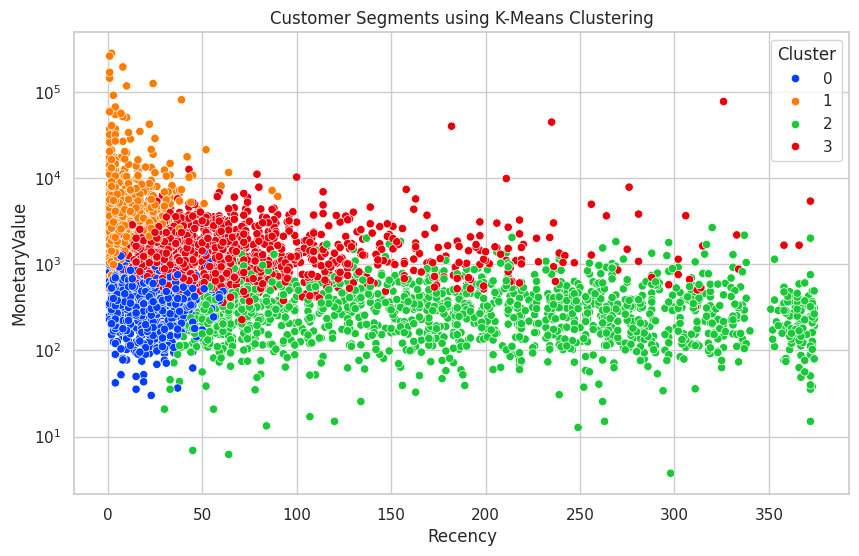

In [55]:

rfm_log = np.log(rfm[['Recency', 'Frequency', 'MonetaryValue']])

# Feature Scal
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log)

#  K-Means Model
kmeans = KMeans(n_clusters=4, init='k-means++', max_iter=300, random_state=42)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)


cluster_summary = rfm.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'MonetaryValue': 'mean'
}).round(2)

print("--- AI Generated Cluster Summary ---")
print(cluster_summary)

# Cluster Visualiazation
plt.figure(figsize=(10, 6))
sns.scatterplot(data=rfm, x='Recency', y='MonetaryValue', hue='Cluster', palette='bright')
plt.title('Customer Segments using K-Means Clustering')
plt.yscale('log') #(log scale use decress value)
plt.show()